# NOTEBOOK 04 - TRADUÇÃO E FILTRO DOS COMENTÁRIOS

## Disciplina: IMD1151 - Ciência de Dados

### Objetivos:
1. Usar LLM para traduzir os comentários para uma linguagem só
2. Aplicar filtro de qualidade para manter apenas reviews substantivas


In [ ]:
# Instalar bibliotecas necessárias
!pip install transformers sentencepiece torch tqdm langdetect --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from langdetect import detect, LangDetectException
from tqdm import tqdm
import warnings
import torch
import re

warnings.filterwarnings('ignore')
tqdm.pandas()

# Verificar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Dispositivo: {device}")

# Configurar visualizações
plt.style.use('default')
sns.set_palette("husl")

🖥️  Dispositivo: cuda


In [ ]:
# Carregar dataset limpo do Notebook 03
df = pd.read_csv('cyberpunk_reviews_clean_ready_for_translation.csv')

print(f"📊 Dataset carregado com sucesso!")
print(f"   Total de reviews: {len(df):,}")
print(f"   Período: {df['created_at'].min()} até {df['created_at'].max()}")
print(f"\n📋 Colunas disponíveis ({len(df.columns)}):")
print(f"   {', '.join(df.columns.tolist())}")

print(f"\n🌍 Distribuição por idioma (campo Steam):")
print(df['language'].value_counts())

print(f"\n📝 Estatísticas de texto:")
print(df[['word_count', 'char_count', 'avg_word_length']].describe())

df.head(3)

📊 Dataset carregado com sucesso!
   Total de reviews: 41,364
   Período: 2020-12-10 00:34:32 até 2025-10-14 21:27:56

📋 Colunas disponíveis (28):
   language, review_text, created_at, is_recommended, helpful_votes, funny_votes, vote_score, num_comments, is_steam_purchase, is_free, num_games_owned, num_reviews, total_playtime_min, playtime_at_review_min, detected_lang, word_count, char_count, avg_word_length, review_length_category, clean_text, total_playtime_hours, playtime_at_review_hours, year, month, year_month, quarter, day_of_week, hour

🌍 Distribuição por idioma (campo Steam):
language
english      34508
brazilian     6856
Name: count, dtype: int64

📝 Estatísticas de texto:
         word_count    char_count  avg_word_length
count  41364.000000  41364.000000     41364.000000
mean      49.511822    272.209482         5.397178
std      104.064936    585.620552         1.695184
min        1.000000      1.000000         1.000000
25%        7.000000     37.000000         4.916667
50%  

,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,...,review_length_category,clean_text,total_playtime_hours,playtime_at_review_hours,year,month,year_month,quarter,day_of_week,hour
0,brazilian,do lixo ao luxo. cyberpunk 2077 é um jogo de r...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,...,Muito Longa (500+),lixo luxo cyberpunk 2077 jogo rpg ação primeir...,149.400000,149.400000,2025,2,2025-02,2025Q1,Sunday,20
1,brazilian,ainda em dúvida se vale a pena jogar cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,...,Longa (100-500),ainda dúvida vale pena jogar cyberpunk 2077 ho...,164.416667,81.983333,2025,8,2025-08,2025Q3,Sunday,18
2,brazilian,cyberpunk 2077 é uma experiência de vida. o me...,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,...,Longa (100-500),cyberpunk 2077 experiência vida melhor jogo jo...,81.633333,76.233333,2024,12,2024-12,2024Q4,Sunday,5


In [ ]:
class SmartNLLBTranslator:
    def __init__(self, model_name="facebook/nllb-200-distilled-600M", device="cpu", batch_size=8):
        """
        detecta idioma + traduz para inglês
        """
        print(f"🔄 Carregando modelo NLLB-200...")
        print(f"   Modelo: {model_name}")
        print(f"   Dispositivo: {device}")

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
        self.device = device
        self.batch_size = batch_size

        self.lang_map = {
            'pt': 'por_Latn',   # Português
            'en': 'eng_Latn',   # Inglês
            'es': 'spa_Latn',   # Espanhol
            'fr': 'fra_Latn',   # Francês
            'de': 'deu_Latn',   # Alemão
            'it': 'ita_Latn',   # Italiano
            'ru': 'rus_Cyrl',   # Russo
            'zh-cn': 'zho_Hans',# Chinês
            'ja': 'jpn_Jpan',   # Japonês
            'ko': 'kor_Hang',   # Coreano
            'tr': 'tur_Latn',   # Turco
            'nl': 'nld_Latn',   # Holandês
            'pl': 'pol_Latn',   # Polonês
            'sv': 'swe_Latn',   # Sueco
        }

        self.target_lang = "eng_Latn"

        print("✅ Modelo carregado com sucesso!")

    def detect_language(self, text):
        """
        Detecta idioma do texto
        """
        if pd.isna(text) or str(text).strip() == "":
            return None

        clean_text = str(text).strip()

        #if len(clean_text) < 20:
            #return None

        try:
            detected = detect(clean_text)
            return detected
        except LangDetectException:
            return None

    def translate_text(self, text, src_lang_code=None, max_length=512):
        """Traduz texto para inglês"""
        if pd.isna(text) or str(text).strip() == "":
            return ""

        text = str(text)

        if src_lang_code is None:
            src_lang_code = self.detect_language(text)

        # Se inglês ou não detectou, retorna original
        if src_lang_code == 'en' or src_lang_code is None:
            return text

        # Converter código ISO para NLLB
        src_lang_nllb = self.lang_map.get(src_lang_code)

        if src_lang_nllb is None:
            return text

        try:
            self.tokenizer.src_lang = src_lang_nllb
            inputs = self.tokenizer(
                text,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            )
            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            with torch.no_grad():
                translated = self.model.generate(
                    **inputs,
                    forced_bos_token_id=self.tokenizer.convert_tokens_to_ids(self.target_lang),
                    max_length=max_length
                )

            translated_text = self.tokenizer.batch_decode(translated, skip_special_tokens=True)[0]
            return translated_text

        except Exception as e:
            print(f"❌ Erro: {e}")
            return text

    def translate_batch(self, texts, src_langs=None, max_length=512):
        """Traduz batch de textos"""
        if not texts:
            return []

        if src_langs is None:
            src_langs = [self.detect_language(t) for t in texts]

        translated = []
        lang_groups = {}

        for i, (text, lang) in enumerate(zip(texts, src_langs)):
            if lang == 'en' or lang is None:
                translated.append((i, text))
                continue

            if lang not in lang_groups:
                lang_groups[lang] = []
            lang_groups[lang].append((i, text))

        for lang_code, group in lang_groups.items():
            indices, group_texts = zip(*group)

            src_lang_nllb = self.lang_map.get(lang_code)
            if src_lang_nllb is None:
                translated.extend(zip(indices, group_texts))
                continue

            try:
                self.tokenizer.src_lang = src_lang_nllb
                inputs = self.tokenizer(
                    list(group_texts),
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=max_length
                )
                inputs = {k: v.to(self.device) for k, v in inputs.items()}

                with torch.no_grad():
                    translated_batch = self.model.generate(
                        **inputs,
                        forced_bos_token_id=self.tokenizer.convert_tokens_to_ids(self.target_lang),
                        max_length=max_length
                    )

                translated_texts = self.tokenizer.batch_decode(translated_batch, skip_special_tokens=True)
                translated.extend(zip(indices, translated_texts))

            except Exception as e:
                print(f"❌ Erro batch {lang_code}: {e}")
                translated.extend(zip(indices, group_texts))

        translated.sort(key=lambda x: x[0])
        return [text for _, text in translated]

    def analyze_and_translate_dataframe(self, df,
                                       clean_text_column='clean_text',
                                       output_column='review_text_en',
                                       detected_lang_column='detected_language_auto'):
        """
        Analisa idiomas e traduz DataFrame completo
        """
        df = df.copy()

        print("=" * 80)
        print("🔍 FASE 1: DETECÇÃO AUTOMÁTICA DE IDIOMA")
        print("=" * 80)
        print(f"   Usando coluna: '{clean_text_column}'")

        # USAR clean_text para detecção!
        df[detected_lang_column] = df[clean_text_column].progress_apply(self.detect_language)

        print(f"\n📊 Idiomas detectados automaticamente:")
        lang_counts = df[detected_lang_column].value_counts()

        lang_names = {
            'en': '🇺🇸 Inglês',
            'pt': '🇧🇷 Português',
            'es': '🇪🇸 Espanhol',
            'fr': '🇫🇷 Francês',
            'de': '🇩🇪 Alemão',
            'ru': '🇷🇺 Russo',
            'it': '🇮🇹 Italiano',
            None: '❓ Não detectado'
        }

        for lang, count in lang_counts.items():
            lang_name = lang_names.get(lang, f'🌍 {lang}')
            print(f"  {lang_name}: {count:,} ({count/len(df)*100:.1f}%)")

        needs_translation = (df[detected_lang_column] != 'en') & (df[detected_lang_column].notna())
        to_translate = needs_translation.sum()

        print(f"\n" + "=" * 80)
        print(f"🌐 FASE 2: TRADUÇÃO PARA INGLÊS")
        print("=" * 80)
        print(f"  Total a traduzir: {to_translate:,} reviews ({to_translate/len(df)*100:.1f}%)")
        print(f"  Manter em inglês: {(~needs_translation).sum():,} reviews")
        print(f"  Batch size: {self.batch_size}")
        print()

        # USAR clean_text para tradução!
        all_texts = df[clean_text_column].tolist()
        all_langs = df[detected_lang_column].tolist()

        translated_texts = []
        for i in tqdm(range(0, len(all_texts), self.batch_size), desc="🌐 Traduzindo"):
            batch_texts = all_texts[i:i + self.batch_size]
            batch_langs = all_langs[i:i + self.batch_size]

            translated_batch = self.translate_batch(batch_texts, batch_langs)
            translated_texts.extend(translated_batch)

        df[output_column] = translated_texts

        print(f"\n✅ Tradução concluída com sucesso!")

        return df

In [ ]:
# Inicializar tradutor inteligente
translator = SmartNLLBTranslator(
    model_name="facebook/nllb-200-distilled-600M",
    device=device,
    batch_size=16 if device == "cuda" else 8
)

🔄 Carregando modelo NLLB-200...
   Modelo: facebook/nllb-200-distilled-600M
   Dispositivo: cuda
✅ Modelo carregado com sucesso!


In [ ]:
df_translated = translator.analyze_and_translate_dataframe(
    df,
    clean_text_column='clean_text',
    output_column='review_text_en',
    detected_lang_column='detected_language_auto'
)

🔍 FASE 1: DETECÇÃO AUTOMÁTICA DE IDIOMA
   Usando coluna: 'clean_text'


100%|██████████| 41364/41364 [03:11<00:00, 216.35it/s]



📊 Idiomas detectados automaticamente:
  🇺🇸 Inglês: 28,150 (68.1%)
  🇧🇷 Português: 4,577 (11.1%)
  🌍 so: 1,266 (3.1%)
  🌍 da: 924 (2.2%)
  🇪🇸 Espanhol: 501 (1.2%)
  🌍 no: 475 (1.1%)
  🇮🇹 Italiano: 422 (1.0%)
  🌍 sk: 420 (1.0%)
  🌍 tl: 401 (1.0%)
  🌍 af: 396 (1.0%)
  🌍 sl: 389 (0.9%)
  🌍 cy: 345 (0.8%)
  🌍 ro: 321 (0.8%)
  🌍 id: 316 (0.8%)
  🌍 ca: 309 (0.7%)
  🌍 nl: 295 (0.7%)
  🇫🇷 Francês: 258 (0.6%)
  🌍 pl: 230 (0.6%)
  🌍 hr: 192 (0.5%)
  🌍 et: 163 (0.4%)
  🌍 fi: 125 (0.3%)
  🌍 sv: 113 (0.3%)
  🇩🇪 Alemão: 85 (0.2%)
  🌍 lt: 82 (0.2%)
  🌍 sq: 69 (0.2%)
  🇷🇺 Russo: 68 (0.2%)
  🌍 sw: 67 (0.2%)
  🌍 hu: 59 (0.1%)
  🌍 tr: 47 (0.1%)
  🌍 lv: 33 (0.1%)
  🌍 ko: 24 (0.1%)
  🌍 cs: 22 (0.1%)
  🌍 zh-cn: 19 (0.0%)
  🌍 vi: 12 (0.0%)
  🌍 th: 12 (0.0%)
  🌍 ar: 9 (0.0%)
  🌍 uk: 5 (0.0%)
  🌍 ja: 3 (0.0%)
  🌍 fa: 1 (0.0%)

🌐 FASE 2: TRADUÇÃO PARA INGLÊS
  Total a traduzir: 13,055 reviews (31.6%)
  Manter em inglês: 28,309 reviews
  Batch size: 16



🌐 Traduzindo: 100%|██████████| 2586/2586 [33:42<00:00,  1.28it/s]


✅ Tradução concluída com sucesso!


In [ ]:
df_translated


,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,...,total_playtime_hours,playtime_at_review_hours,year,month,year_month,quarter,day_of_week,hour,detected_language_auto,review_text_en
0,brazilian,do lixo ao luxo. cyberpunk 2077 é um jogo de r...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,...,149.400000,149.400000,2025,2,2025-02,2025Q1,Sunday,20,pt,The game is being updated corrected content ad...
1,brazilian,ainda em dúvida se vale a pena jogar cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,...,164.416667,81.983333,2025,8,2025-08,2025Q3,Sunday,18,pt,DLC still asking game deserves time know relea...
2,brazilian,cyberpunk 2077 é uma experiência de vida. o me...,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,...,81.633333,76.233333,2024,12,2024-12,2024Q4,Sunday,5,pt,Cyberpunk 2077 life experience best game I pla...
3,brazilian,eu comprei cyberpunk na pre venda em 2020 e po...,2025-06-16 07:33:42,True,53,2,0.844979,0,True,False,...,253.950000,210.566667,2025,6,2025-06,2025Q2,Monday,7,pt,I bought cyberpunk pre sale 2020 can I talk to...
4,brazilian,cyberpunk 2077 é um jogo excepcional que se de...,2024-11-28 00:32:22,True,67,0,0.837374,8,True,False,...,276.216667,114.783333,2024,11,2024-11,2024Q4,Thursday,0,pt,Cyberpunk 2077 exceptional game highlights sev...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41359,english,very nice,2025-07-21 05:52:16,True,0,0,0.500000,0,True,False,...,61.900000,59.900000,2025,7,2025-07,2025Q3,Monday,5,pl,Nice .
41360,english,great,2025-07-21 05:10:11,True,0,0,0.500000,0,True,False,...,122.350000,116.650000,2025,7,2025-07,2025Q3,Monday,5,ro,great
41361,english,10/10,2025-07-21 02:36:18,True,0,0,0.500000,0,True,False,...,80.350000,32.416667,2025,7,2025-07,2025Q3,Monday,2,None,10 10
41362,english,"haank! hank, don't abbreviate cyberpunk. haank!",2025-07-21 00:58:47,True,0,0,0.500000,0,True,False,...,182.800000,173.183333,2025,7,2025-07,2025Q3,Monday,0,af,haank hank dont abbreviate cyberpunk haank


In [ ]:
df_translated.drop('detected_language_auto', axis=1 , inplace=True)

In [ ]:
output_file = 'cyberpunk_reviews.csv'
df_translated.to_csv(output_file, index=False)

RECALCULANDO AS ESTATISTICAS DOS COMENTÁRIOS SOBRE O TEXTO AGORA TRADUZIDO

In [ ]:
df_translated['word_count'] = df_translated['review_text_en'].astype(str).str.split().str.len()
df_translated['char_count'] = df_translated['review_text_en'].astype(str).str.len()
df_translated['avg_word_length'] = df_translated['char_count'] / df_translated['word_count']

print("Estatísticas do texto em inglês")
print(df_translated[['word_count', 'char_count', 'avg_word_length']].describe())

NameError: name 'df_translated' is not defined

In [ ]:
df_translated['review_length_category'] = pd.cut(
    df_translated['word_count'],
    bins=[0, 5, 20, 100, 500, float('inf')],
    labels=['Muito Curta (<5)', 'Curta (5-20)', 'Média (20-100)',
            'Longa (100-500)', 'Muito Longa (500+)']
)

print("DISTRIBUIÇÃO POR TAMANHO:")
print(df_translated['review_length_category'].value_counts().sort_index())

NameError: name 'pd' is not defined

REALIZANDO O FILTRO NOS COMENTÁRIOS PARA REALIZAR ANÁLISE DOS TEXTOS NOVAMENTE SEM OS OUTLIERS

In [ ]:
MIN_WORDS_EN = 15
MAX_WORDS_EN = 300
MIN_CHARS_EN = 100
MAX_CHARS_EN = 2000


print(f"Filtros aplicados:")
print(f"Palavras: {MIN_WORDS_EN} a {MAX_WORDS_EN}")
print(f"Caracteres: {MIN_CHARS_EN} a {MAX_CHARS_EN}")

df_filtered = df_translated[
    (df_translated['word_count'] >= MIN_WORDS_EN) &
    (df_translated['word_count'] <= MAX_WORDS_EN) &
    (df_translated['char_count'] >= MIN_CHARS_EN) &
    (df_translated['char_count'] <= MAX_CHARS_EN)
].copy()

total_original = len(df_translated)
total_filtered = len(df_filtered)
removed = total_original - total_filtered
retention_rate = (total_filtered / total_original) * 100

print(f"Total original: {total_original:,} reviews")
print(f"Mantidas: {total_filtered:,} reviews ({retention_rate:.1f}%)")
print(f"Removidas: {removed:,} reviews ({100-retention_rate:.1f}%)")

print(f"Estatísticas das reviews FILTRADAS:")
print(df_filtered[['word_count', 'char_count', 'avg_word_length']].describe())

Filtros aplicados:
Palavras: 15 a 300
Caracteres: 100 a 2000
Total original: 41,364 reviews
Mantidas: 14,491 reviews (35.0%)
Removidas: 26,873 reviews (65.0%)
Estatísticas das reviews FILTRADAS:
         word_count    char_count  avg_word_length
count  14491.000000  14491.000000     14491.000000
mean      54.204196    356.753433         6.521147
std       47.771608    323.918419         0.592580
min       15.000000    100.000000         3.491124
25%       23.000000    145.000000         6.143791
50%       36.000000    231.000000         6.520000
75%       66.000000    433.000000         6.880217
max      300.000000   1993.000000        11.653543


In [ ]:
print("DISTRIBUIÇÃO POR TAMANHO:")
print(df_filtered['review_length_category'].value_counts().sort_index())

DISTRIBUIÇÃO POR TAMANHO:
review_length_category
Muito Curta (<5)         0
Curta (5-20)          2610
Média (20-100)        9910
Longa (100-500)       1971
Muito Longa (500+)       0
Name: count, dtype: int64


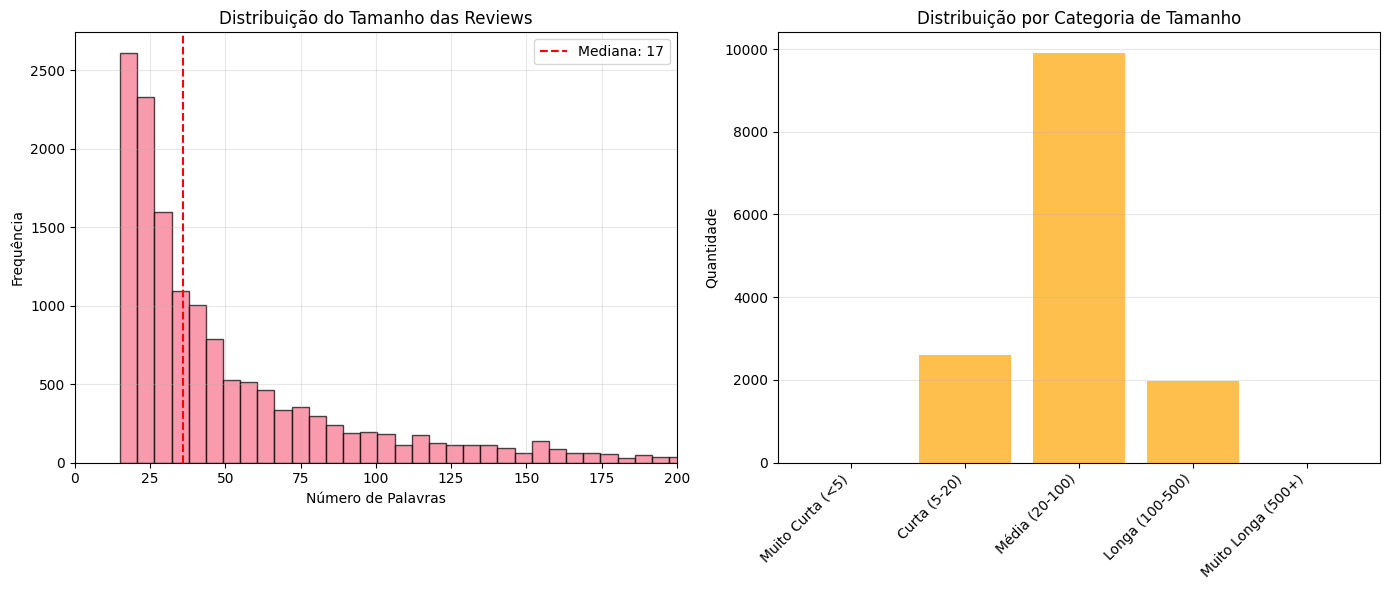

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribuição de tamanho do comentário
axes[0].hist(df_filtered['word_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df_filtered['word_count'].median(), color='red', linestyle='--',
                label=f'Mediana: {df["word_count"].median():.0f}')
axes[0].set_xlabel('Número de Palavras')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do Tamanho das Reviews')
axes[0].legend()
axes[0].set_xlim(0, 200)
axes[0].grid(alpha=0.3)

# Categorias de tamanho
size_counts = df_filtered['review_length_category'].value_counts().sort_index()
axes[1].bar(range(len(size_counts)), size_counts.values, alpha=0.7, color='orange')
axes[1].set_xticks(range(len(size_counts)))
axes[1].set_xticklabels(size_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Quantidade')
axes[1].set_title('Distribuição por Categoria de Tamanho')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

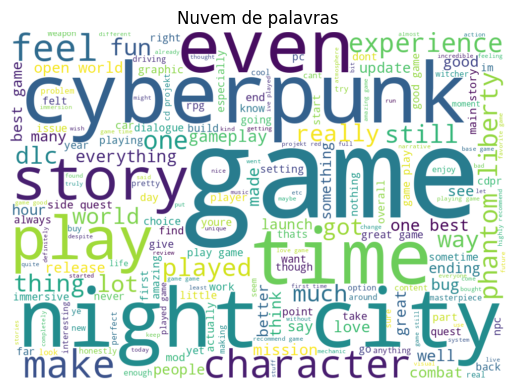

In [ ]:
from wordcloud import WordCloud

texto = ' '.join(df_filtered['review_text_en'].astype(str))
wordcloud = WordCloud(width=1000, height=700, background_color='white').generate(texto)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nuvem de palavras")
plt.show()

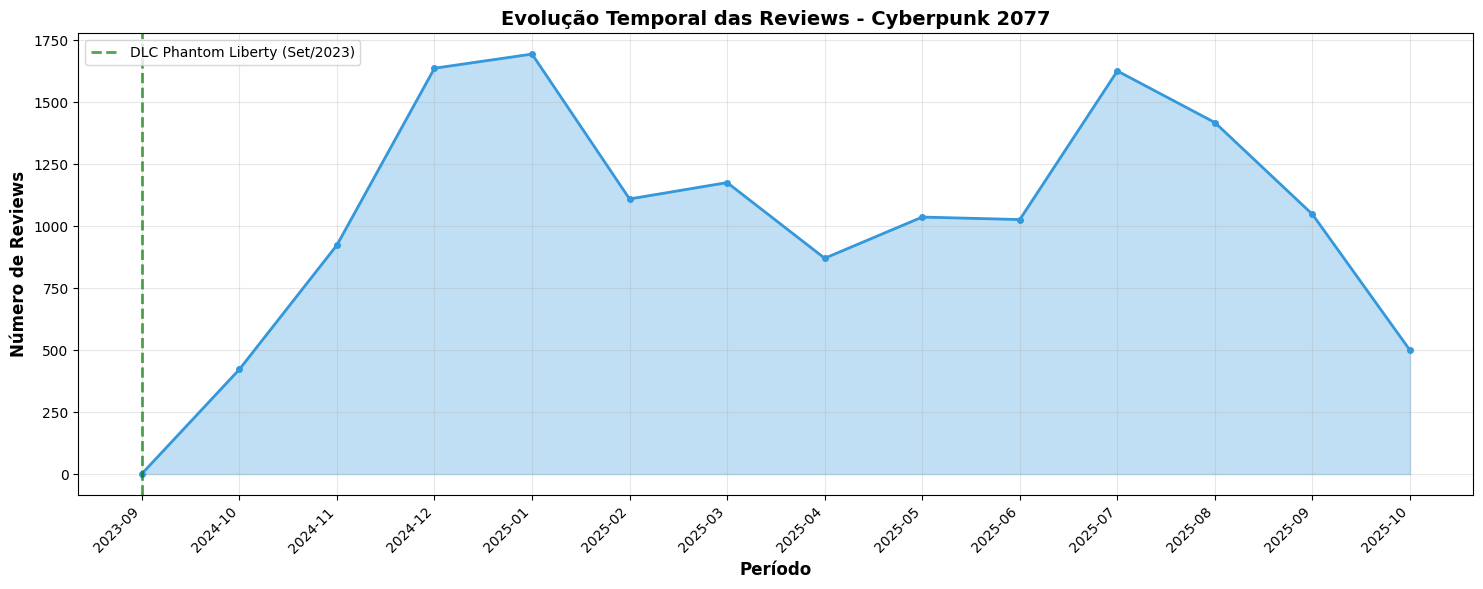

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(18, 6))

reviews_per_month = df_filtered.groupby('year_month').size()

dlc_date = pd.Period('2023-09', 'M')
reviews_per_month.index = pd.PeriodIndex(reviews_per_month.index, freq='M')
reviews_per_month = reviews_per_month[reviews_per_month.index >= dlc_date]



ax1.plot(reviews_per_month.index.astype(str), reviews_per_month.values,
         linewidth=2, marker='o', markersize=4, color='#3498db')
ax1.fill_between(range(len(reviews_per_month)), reviews_per_month.values,
                 alpha=0.3, color='#3498db')

if dlc_date in reviews_per_month.index:
    dlc_idx = list(reviews_per_month.index).index(dlc_date)
    ax1.axvline(dlc_idx, color='green', linestyle='--', linewidth=2, alpha=0.7,
                label='DLC Phantom Liberty (Set/2023)')

ax1.set_xlabel('Período', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número de Reviews', fontsize=12, fontweight='bold')
ax1.set_title('Evolução Temporal das Reviews - Cyberpunk 2077', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

step = max(1, len(reviews_per_month) // 20)
if step == 0: step = 1

ax1.set_xticks(range(0, len(reviews_per_month), step))
ax1.set_xticklabels([str(x) for x in reviews_per_month.index[::step]], rotation=45, ha='right')

plt.show()

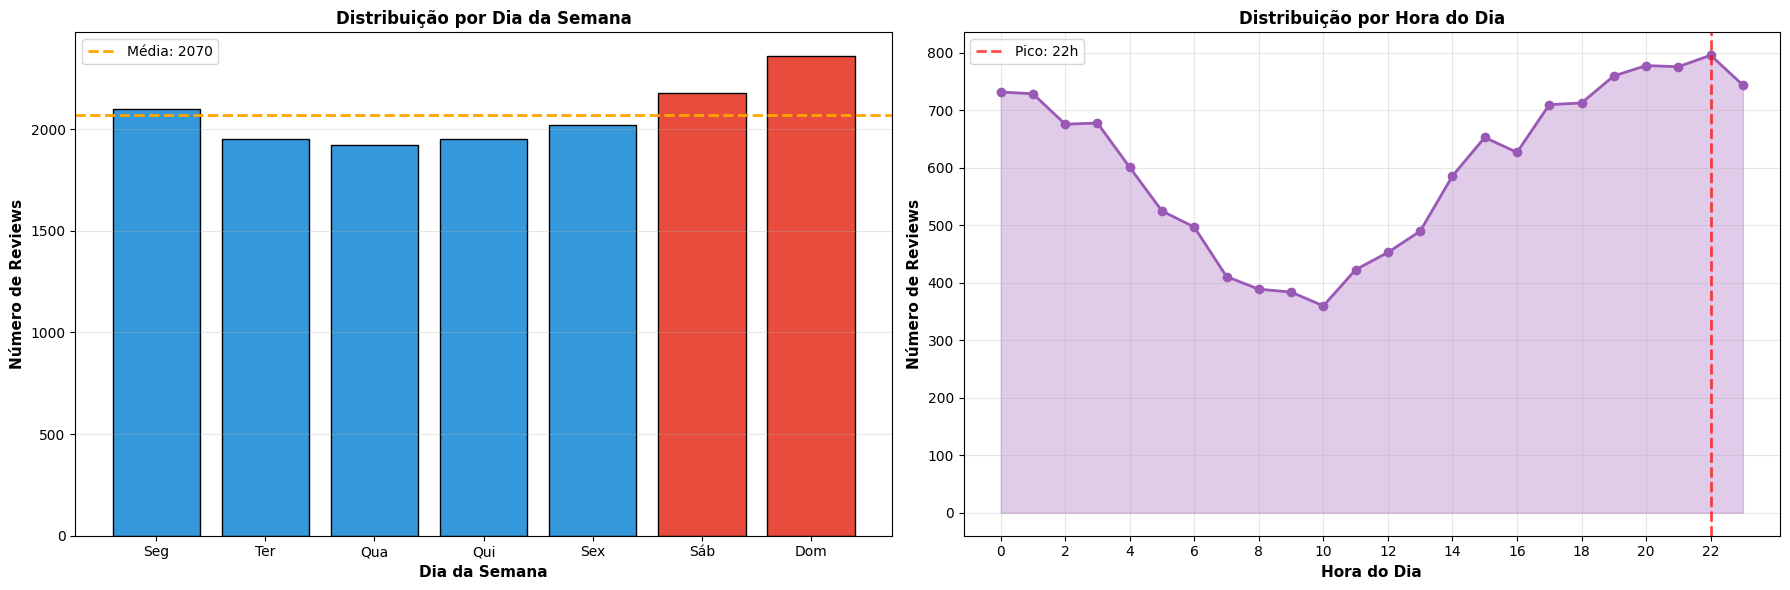

In [ ]:
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(18, 6))

# Distribuição por Dia da Semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_abbr = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

day_counts = df_filtered['day_of_week'].value_counts()
day_counts = day_counts.reindex(day_order)

colors_day = ['#e74c3c' if day in ['Saturday', 'Sunday'] else '#3498db' for day in day_order]

ax5.bar(day_abbr, day_counts.values, color=colors_day, edgecolor='black', linewidth=1)
ax5.set_xlabel('Dia da Semana', fontsize=11, fontweight='bold')
ax5.set_ylabel('Número de Reviews', fontsize=11, fontweight='bold')
ax5.set_title('Distribuição por Dia da Semana', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

mean_line = day_counts.mean()
ax5.axhline(y=mean_line, color='orange', linestyle='--', linewidth=2, label=f'Média: {mean_line:.0f}')
ax5.legend()

# Distribuição por Hora do Dia
hour_counts = df_filtered['hour'].value_counts().sort_index()

ax6.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, markersize=6, color='#9b59b6')
ax6.fill_between(hour_counts.index, hour_counts.values, alpha=0.3, color='#9b59b6')

peak_hour = hour_counts.idxmax()
ax6.axvline(x=peak_hour, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Pico: {peak_hour}h')

ax6.set_xlabel('Hora do Dia', fontsize=11, fontweight='bold')
ax6.set_ylabel('Número de Reviews', fontsize=11, fontweight='bold')
ax6.set_title('Distribuição por Hora do Dia', fontsize=12, fontweight='bold')
ax6.set_xticks(range(0, 24, 2))
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ANÁLISE UNIVARIADA PÓS FILTRO DOS COMENTÁRIOS

Distribuição de Sentimento:
Positivas (Recomenda): 13,006 (89.8%)
Negativas (Não recomenda): 1,485 (10.2%)


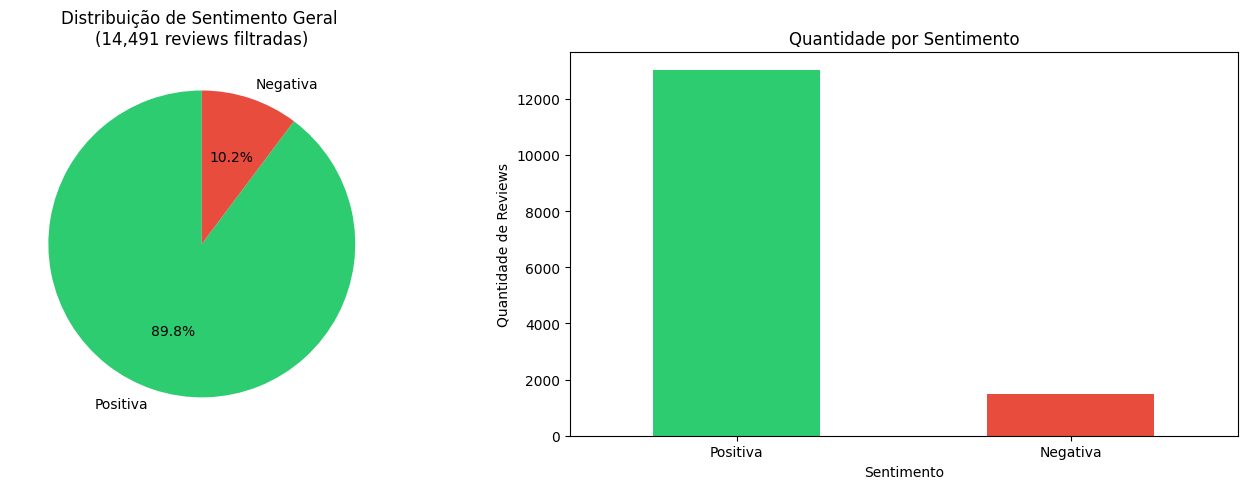

In [ ]:
sentiment_counts = df_filtered['is_recommended'].value_counts()
total = len(df_filtered)

print(f"Distribuição de Sentimento:")
print(f"Positivas (Recomenda): {sentiment_counts[True]:,} ({sentiment_counts[True]/total*100:.1f}%)")
print(f"Negativas (Não recomenda): {sentiment_counts[False]:,} ({sentiment_counts[False]/total*100:.1f}%)")

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(sentiment_counts.values, labels=['Positiva', 'Negativa'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Distribuição de Sentimento Geral \n(14,491 reviews filtradas)')

sentiment_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_xlabel('Sentimento')
axes[1].set_ylabel('Quantidade de Reviews')
axes[1].set_title('Quantidade por Sentimento')
axes[1].set_xticklabels(['Positiva', 'Negativa'], rotation=0)

plt.tight_layout()
plt.show()


Estatísticas de Tempo de Jogo:
       total_playtime_hours  playtime_at_review_hours
count          14491.000000              14491.000000
mean             157.148458                117.513585
std              226.647368                192.377765
min                0.083333                  0.083333
25%               59.491667                 34.075000
50%              108.000000                 74.900000
75%              184.783333                141.641667
max            10607.433333               8836.433333


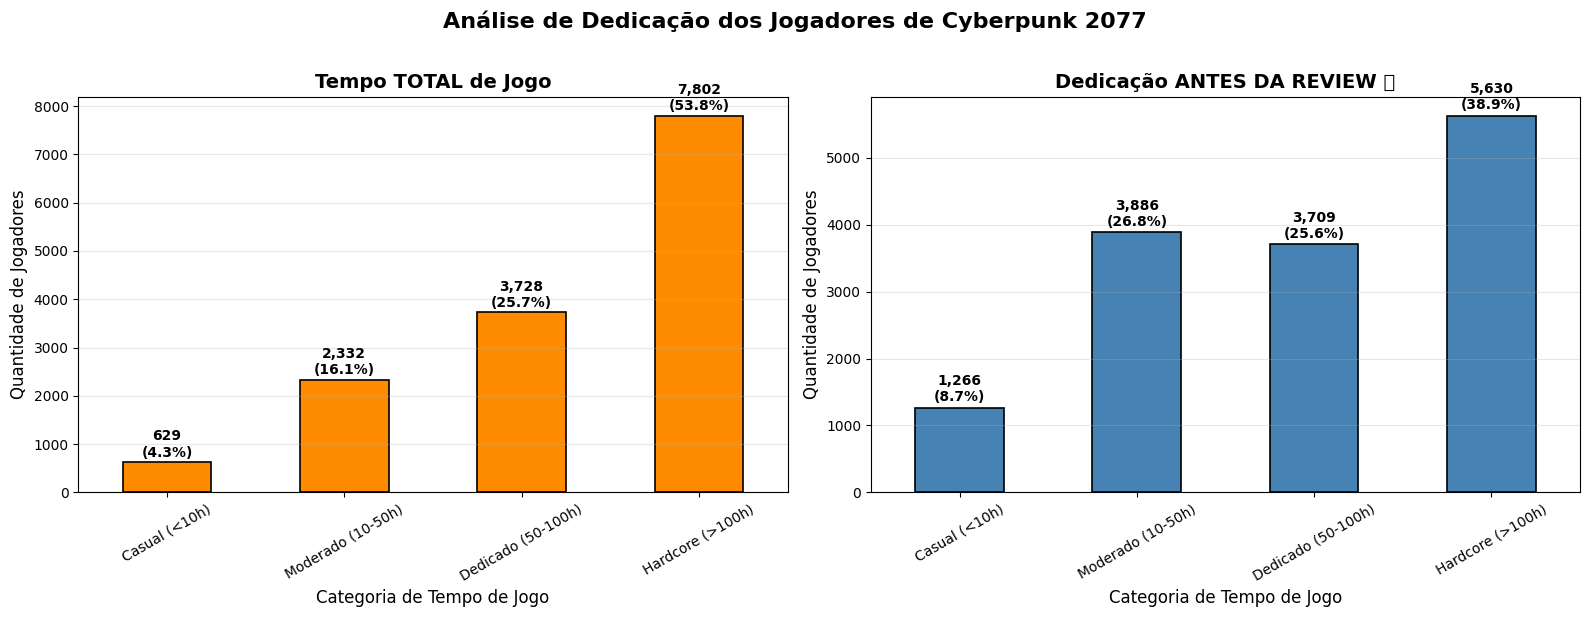


CONTINUIDADE:
Jogadores continuaram jogando significativamente após fazer a review
(média de 39.6h adicionais após comentar)


In [ ]:
print(f"Estatísticas de Tempo de Jogo:")
print(df_filtered[['total_playtime_hours', 'playtime_at_review_hours']].describe())

def categorize_playtime(hours):
    if hours < 10:
        return 'Casual (<10h)'
    elif hours < 50:
        return 'Moderado (10-50h)'
    elif hours < 100:
        return 'Dedicado (50-100h)'
    else:
        return 'Hardcore (>100h)'

df_filtered['playtime_category_total'] = df_filtered['total_playtime_hours'].apply(categorize_playtime)
df_filtered['playtime_category_at_review'] = df_filtered['playtime_at_review_hours'].apply(categorize_playtime)

playtime_dist_total = df_filtered['playtime_category_total'].value_counts()
playtime_dist_review = df_filtered['playtime_category_at_review'].value_counts()

categories_order = ['Casual (<10h)', 'Moderado (10-50h)', 'Dedicado (50-100h)', 'Hardcore (>100h)']


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Tempo TOTAL de Jogo
playtime_dist_total.reindex(categories_order, fill_value=0).plot(
    kind='bar', ax=axes[0], color='darkorange', edgecolor='black', linewidth=1.2
)
axes[0].set_xlabel('Categoria de Tempo de Jogo', fontsize=12)
axes[0].set_ylabel('Quantidade de Jogadores', fontsize=12)
axes[0].set_title('Tempo TOTAL de Jogo', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (cat, value) in enumerate(playtime_dist_total.reindex(categories_order, fill_value=0).items()):
    if value > 0:
        axes[0].text(i, value + 50, f'{value:,}\n({value/len(df_filtered)*100:.1f}%)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gráfico 2: Tempo NO MOMENTO DA REVIEW (Dedicação)
playtime_dist_review.reindex(categories_order, fill_value=0).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black', linewidth=1.2
)
axes[1].set_xlabel('Categoria de Tempo de Jogo', fontsize=12)
axes[1].set_ylabel('Quantidade de Jogadores', fontsize=12)
axes[1].set_title('Dedicação ANTES DA REVIEW ⭐', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (cat, value) in enumerate(playtime_dist_review.reindex(categories_order, fill_value=0).items()):
    if value > 0:
        axes[1].text(i, value + 50, f'{value:,}\n({value/len(df_filtered)*100:.1f}%)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Análise de Dedicação dos Jogadores de Cyberpunk 2077',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Diferença entre total e review
diff_hours = df_filtered['total_playtime_hours'].mean() - df_filtered['playtime_at_review_hours'].mean()
print(f"\nCONTINUIDADE:")
if diff_hours > 5:
    print(f"Jogadores continuaram jogando significativamente após fazer a review")
    print(f"(média de {diff_hours:.1f}h adicionais após comentar)")
elif diff_hours > 1:
    print(f"Jogadores jogaram um pouco mais após a review ({diff_hours:.1f}h)")
else:
    print(f"Reviews foram feitas próximo ao tempo total atual de jogo")

In [ ]:
print(f"Estatísticas de Helpful Votes:")
print(df_filtered['helpful_votes'].describe())

# Reviews com mais vots
top_helpful = df_filtered.nlargest(5, 'helpful_votes')[['helpful_votes', 'is_recommended', 'word_count', 'review_text_en']]

print(f"\n\nTop 5 Reviews mais votados:")
for idx, row in top_helpful.iterrows():
    sentiment = "Positiva" if row['is_recommended'] else "Negativa"
    print(f"   {row['helpful_votes']} votes | {sentiment} | {row['word_count']} palavras")
    print(f"   {row['review_text_en'][:150]}...")
    print()



Estatísticas de Helpful Votes:
count    14491.000000
mean         2.431095
std         36.257476
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       2236.000000
Name: helpful_votes, dtype: float64


Top 5 Reviews Mais Úteis:
   2236 votes | Positiva | 30 palavras
   The game is now available in the form of a free download full english dublagem part properties library cyberpunk properties language tchau brigade cov...

   1510 votes | Positiva | 146 palavras
   graphics forget reality beautiful good decent bad look long get eye cancer gameplay good good gameplay mehh watch paint dry instead audio eargasm good...

   1336 votes | Positiva | 154 palavras
   graphics forget reality beautiful good decent bad look long msdos gameplay good good gameplay mehh watch paint dry instead dont audio eargasm good goo...

   1067 votes | Positiva | 154 palavras
   graphics forget reality beautiful good decent bad look long msdos gameplay good good gameplay

In [ ]:
!pip install plotly --quiet

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [ ]:
df_2024_2025 = df_filtered[df_filtered['year'] >= 2024].copy()

print(f"Período analisado: 2024-2025")
print(f"Total de reviews: {len(df_2024_2025):,}")
print(f"Recomendadas: {df_2024_2025['is_recommended'].sum():,} ({df_2024_2025['is_recommended'].mean()*100:.1f}%)")
print(f"Não recomendadas: {(~df_2024_2025['is_recommended']).sum():,} ({(~df_2024_2025['is_recommended']).mean()*100:.1f}%)")

# Preparar dados temporais
temporal_sentiment = df_2024_2025.groupby('year_month').agg({
    'is_recommended': ['sum', 'count', 'mean']
}).reset_index()

temporal_sentiment.columns = ['year_month', 'recommended_count', 'total_count', 'recommended_pct']
temporal_sentiment['not_recommended_count'] = temporal_sentiment['total_count'] - temporal_sentiment['recommended_count']
temporal_sentiment['not_recommended_pct'] = (1 - temporal_sentiment['recommended_pct']) * 100
temporal_sentiment['recommended_pct'] = temporal_sentiment['recommended_pct'] * 100

temporal_sentiment = temporal_sentiment.sort_values('year_month')

print(f"Evolução mensal:")
for _, row in temporal_sentiment.iterrows():
    print(f"   {row['year_month']}: {row['recommended_pct']:.1f}% positivas ({row['total_count']:,} reviews)")

fig_line = go.Figure()

# Linha: % Recomendadas
fig_line.add_trace(go.Scatter(
    x=temporal_sentiment['year_month'],
    y=temporal_sentiment['recommended_pct'],
    mode='lines+markers',
    name='👍 Recomendadas',
    line=dict(color='#2ecc71', width=3),
    marker=dict(size=10, symbol='circle'),
    hovertemplate='<b>%{x}</b><br>Recomendadas: %{y:.1f}%<br><extra></extra>'
))

# Linha: % Não Recomendadas
fig_line.add_trace(go.Scatter(
    x=temporal_sentiment['year_month'],
    y=temporal_sentiment['not_recommended_pct'],
    mode='lines+markers',
    name='👎 Não Recomendadas',
    line=dict(color='#e74c3c', width=3),
    marker=dict(size=10, symbol='square'),
    hovertemplate='<b>%{x}</b><br>Não Recomendadas: %{y:.1f}%<br><extra></extra>'
))

# Linha de referência 50%
fig_line.add_hline(
    y=50,
    line_dash="dash",
    line_color="gray",
    line_width=2,
    annotation_text="50% (Neutro)",
    annotation_position="right"
)

# Layout
fig_line.update_layout(
    title={
        'text': '<b>Evolução do Sentimento ao Longo do Tempo (2024-2025)</b><br>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20}
    },
    xaxis_title='<b>Período (Ano-Mês)</b>',
    yaxis_title='<b>Percentual (%)</b>',
    yaxis=dict(range=[0, 100], ticksuffix='%'),
    hovermode='x unified',
    template='plotly_white',
    font=dict(size=12),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        font=dict(size=14)
    ),
    height=600,
    showlegend=True
)

max_pos_idx = temporal_sentiment['recommended_pct'].idxmax()
max_pos_row = temporal_sentiment.loc[max_pos_idx]

fig_line.add_annotation(
    x=max_pos_row['year_month'],
    y=max_pos_row['recommended_pct'],
    text=f"Pico: {max_pos_row['recommended_pct']:.1f}%",
    showarrow=True,
    arrowhead=2,
    arrowcolor='#2ecc71',
    ax=0,
    ay=-40,
    font=dict(color='#2ecc71', size=12, family='Arial Black')
)

min_pos_idx = temporal_sentiment['recommended_pct'].idxmin()
min_pos_row = temporal_sentiment.loc[min_pos_idx]

fig_line.add_annotation(
    x=min_pos_row['year_month'],
    y=min_pos_row['recommended_pct'],
    text=f"Baixa: {min_pos_row['recommended_pct']:.1f}%",
    showarrow=True,
    arrowhead=2,
    arrowcolor='#e74c3c',
    ax=0,
    ay=40,
    font=dict(color='#e74c3c', size=12, family='Arial Black')
)

fig_line.show()

Período analisado: 2024-2025
Total de reviews: 14,478
Recomendadas: 12,995 (89.8%)
Não recomendadas: 1,483 (10.2%)
Evolução mensal:
   2024-10: 93.4% positivas (422 reviews)
   2024-11: 90.1% positivas (923 reviews)
   2024-12: 90.2% positivas (1,636 reviews)
   2025-01: 90.7% positivas (1,693 reviews)
   2025-02: 90.6% positivas (1,109 reviews)
   2025-03: 90.1% positivas (1,175 reviews)
   2025-04: 92.1% positivas (870 reviews)
   2025-05: 86.9% positivas (1,036 reviews)
   2025-06: 90.8% positivas (1,026 reviews)
   2025-07: 89.2% positivas (1,625 reviews)
   2025-08: 88.1% positivas (1,417 reviews)
   2025-09: 88.9% positivas (1,047 reviews)
   2025-10: 86.6% positivas (499 reviews)


In [ ]:
fig_bars = go.Figure()

# Barras: Recomendadas
fig_bars.add_trace(go.Bar(
    x=temporal_sentiment['year_month'],
    y=temporal_sentiment['recommended_count'],
    name='👍 Recomendadas',
    marker_color='#2ecc71',
    marker_line_color='black',
    marker_line_width=1,
    text=temporal_sentiment['recommended_count'],
    textposition='outside',
    texttemplate='%{text:,}',
    hovertemplate='<b>%{x}</b><br>Recomendadas: %{y:,}<br><extra></extra>'
))

# Barras: Não Recomendadas
fig_bars.add_trace(go.Bar(
    x=temporal_sentiment['year_month'],
    y=temporal_sentiment['not_recommended_count'],
    name='👎 Não Recomendadas',
    marker_color='#e74c3c',
    marker_line_color='black',
    marker_line_width=1,
    text=temporal_sentiment['not_recommended_count'],
    textposition='outside',
    texttemplate='%{text:,}',
    hovertemplate='<b>%{x}</b><br>Não Recomendadas: %{y:,}<br><extra></extra>'
))

# Layout
fig_bars.update_layout(
    title={
        'text': '<b>Quantidade de Reviews por Sentimento (2024-2025)</b><br>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20}
    },
    xaxis_title='<b>Período (Ano-Mês)</b>',
    yaxis_title='<b>Quantidade de Reviews</b>',
    barmode='group',
    template='plotly_white',
    font=dict(size=12),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        font=dict(size=14)
    ),
    height=600,
    hovermode='x unified',
    bargap=0.15,
    bargroupgap=0.1
)

fig_bars.show()

